# Feature Engineering

---

1. Import packages
2. Load data
3. Feature engineering

---

## 1. Import packages

In [336]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

---
## 2. Load data

In [337]:
# Converts the date_activ, date_end, date_modif_prod, and date_renewal columns into proper datetime format (year-month-day).

df = pd.read_csv('./clean_data_after_eda.csv')
df["date_activ"] = pd.to_datetime(df["date_activ"], format='%Y-%m-%d')
df["date_end"] = pd.to_datetime(df["date_end"], format='%Y-%m-%d')
df["date_modif_prod"] = pd.to_datetime(df["date_modif_prod"], format='%Y-%m-%d')
df["date_renewal"] = pd.to_datetime(df["date_renewal"], format='%Y-%m-%d')

In [338]:
# Check first five rows in df

df.head(3)

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0.000131,4.100838e-05,0.000908,2.086294,99.530517,44.235794,2.086425,9.953056e+01,44.236702,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,0.000003,1.217891e-03,0.000000,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,0.000004,9.450150e-08,0.000000,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000,0


---

## 3. Feature engineering

Difference between off-peak prices in December and preceding January



In [339]:
# Load price_df
# Convert price_date column to a proper date format
price_df = pd.read_csv('price_data.csv')
price_df["price_date"] = pd.to_datetime(price_df["price_date"], format='%Y-%m-%d') 
price_df.head(12)

,id,price_date,price_off_peak_var,price_peak_var,price_mid_peak_var,price_off_peak_fix,price_peak_fix,price_mid_peak_fix
0,038af19179925da21a25619c5a24b745,2015-01-01,0.151367,0.0,0.0,44.266931,0.0,0.0
1,038af19179925da21a25619c5a24b745,2015-02-01,0.151367,0.0,0.0,44.266931,0.0,0.0
2,038af19179925da21a25619c5a24b745,2015-03-01,0.151367,0.0,0.0,44.266931,0.0,0.0
3,038af19179925da21a25619c5a24b745,2015-04-01,0.149626,0.0,0.0,44.266931,0.0,0.0
4,038af19179925da21a25619c5a24b745,2015-05-01,0.149626,0.0,0.0,44.266931,0.0,0.0
5,038af19179925da21a25619c5a24b745,2015-06-01,0.149626,0.0,0.0,44.266930,0.0,0.0
6,038af19179925da21a25619c5a24b745,2015-07-01,0.150321,0.0,0.0,44.444710,0.0,0.0
7,038af19179925da21a25619c5a24b745,2015-08-01,0.145859,0.0,0.0,44.444710,0.0,0.0
8,038af19179925da21a25619c5a24b745,2015-09-01,0.145859,0.0,0.0,44.444710,0.0,0.0
9,038af19179925da21a25619c5a24b745,2015-10-01,0.145859,0.0,0.0,44.444710,0.0,0.0


In [340]:
# Confirm the dataset consist of all months data for all clients/customers 
price_df['price_date'].unique()

<DatetimeArray>
['2015-01-01 00:00:00', '2015-02-01 00:00:00', '2015-03-01 00:00:00',
 '2015-04-01 00:00:00', '2015-05-01 00:00:00', '2015-06-01 00:00:00',
 '2015-07-01 00:00:00', '2015-08-01 00:00:00', '2015-09-01 00:00:00',
 '2015-10-01 00:00:00', '2015-11-01 00:00:00', '2015-12-01 00:00:00']
Length: 12, dtype: datetime64[ns]

This reveals patterns of energy and power price changes over the year

In [341]:
# Group off-peak prices by companies and month
monthly_price_by_id = price_df.groupby(['id', 'price_date']).agg({'price_off_peak_var': 'mean', 'price_off_peak_fix': 'mean'}).reset_index()

# Get january and december prices
jan_prices = monthly_price_by_id.groupby('id').first().reset_index()
dec_prices = monthly_price_by_id.groupby('id').last().reset_index()

# Calculate the difference
# Calculate relative change
# Calculate Energy-power ratio
# Calculate energy and power ratio for jan and dec
diff = pd.merge(dec_prices.rename(columns={'price_off_peak_var': 'dec_1', 'price_off_peak_fix': 'dec_2'}), jan_prices.drop(columns='price_date'), on='id')
diff['offpeak_diff_dec_january_energy'] = diff['dec_1'] - diff['price_off_peak_var']
diff['offpeak_diff_dec_january_power'] = diff['dec_2'] - diff['price_off_peak_fix']
diff['offpeak_growth_ratio_dec_january_energy'] = (diff['dec_1'] - diff['price_off_peak_var']) / diff['price_off_peak_var']
diff['offpeak_growth_ratio_dec_january_power'] = (diff['dec_2'] - diff['price_off_peak_fix'])/ diff['price_off_peak_fix']
diff['energy_power_time_dec'] = diff['dec_1'] / diff['dec_2']
diff['energy_power_time_jan'] = diff['price_off_peak_var'] / diff['price_off_peak_fix']
diff['energy_ratio_jan_dec'] = diff['price_off_peak_var'] / diff['dec_1']
diff['power_ratio_jan_dec'] = diff['price_off_peak_fix'] / diff['dec_2']

diff = diff[['id', 'offpeak_diff_dec_january_energy','offpeak_diff_dec_january_power', 
             'offpeak_growth_ratio_dec_january_energy', 'offpeak_growth_ratio_dec_january_power',
             'energy_power_time_jan', 'energy_power_time_dec', 'energy_ratio_jan_dec', 
             'power_ratio_jan_dec'
            ]]
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,offpeak_growth_ratio_dec_january_energy,offpeak_growth_ratio_dec_january_power,energy_power_time_jan,energy_power_time_dec,energy_ratio_jan_dec,power_ratio_jan_dec
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916,-0.049105,4.016066e-03,0.003108,0.002944,1.051640,0.996000
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779,-0.027721,4.016063e-03,0.003344,0.003239,1.028511,0.996000
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000,0.334421,3.374980e-02,0.003394,0.004381,0.749389,0.967352
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916,-0.081390,4.016066e-03,0.003034,0.002776,1.088602,0.996000
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001,-0.026728,-2.710827e-08,0.003376,0.003286,1.027461,1.000000


Price changes on average over diferent periods namely Off peak, mid peak and peak

In [342]:
average_price = price_df.groupby('id', as_index=False)[[
    'price_off_peak_var', 'price_peak_var', 'price_mid_peak_var',
    'price_off_peak_fix', 'price_peak_fix', 'price_mid_peak_fix'
]].mean()

average_price['off_peak_peak_var_mean_diff'] = average_price['price_off_peak_var'] - average_price['price_peak_var']
average_price['peak_mid_peak_var_mean_diff'] = average_price['price_peak_var'] - average_price['price_mid_peak_var']
average_price['off_peak_mid_peak_var_mean_diff'] = average_price['price_off_peak_var'] - average_price['price_mid_peak_var']
average_price['off_peak_peak_fix_mean_diff'] = average_price['price_off_peak_fix'] - average_price['price_peak_fix']
average_price['peak_mid_peak_fix_mean_diff'] = average_price['price_peak_fix'] - average_price['price_mid_peak_fix']
average_price['off_peak_mid_peak_fix_mean_diff'] = average_price['price_off_peak_fix'] - average_price['price_mid_peak_fix']

average_diff_cols = [
    'id', 
    'off_peak_peak_var_mean_diff',
    'peak_mid_peak_var_mean_diff', 
    'off_peak_mid_peak_var_mean_diff',
    'off_peak_peak_fix_mean_diff', 
    'peak_mid_peak_fix_mean_diff', 
    'off_peak_mid_peak_fix_mean_diff'
]
diff = pd.merge(diff, average_price[average_diff_cols], on='id')
diff.head()

,id,offpeak_diff_dec_january_energy,offpeak_diff_dec_january_power,offpeak_growth_ratio_dec_january_energy,offpeak_growth_ratio_dec_january_power,energy_power_time_jan,energy_power_time_dec,energy_ratio_jan_dec,power_ratio_jan_dec,off_peak_peak_var_mean_diff,peak_mid_peak_var_mean_diff,off_peak_mid_peak_var_mean_diff,off_peak_peak_fix_mean_diff,peak_mid_peak_fix_mean_diff,off_peak_mid_peak_fix_mean_diff
0,0002203ffbb812588b632b9e628cc38d,-0.006192,0.162916,-0.049105,4.016066e-03,0.003108,0.002944,1.051640,0.996000,0.020545,0.030633,0.051178,16.280694,8.140345,24.421038
1,0004351ebdd665e6ee664792efc4fd13,-0.004104,0.177779,-0.027721,4.016063e-03,0.003344,0.003239,1.028511,0.996000,0.146426,0.000000,0.146426,44.385450,0.000000,44.385450
2,0010bcc39e42b3c2131ed2ce55246e3c,0.050443,1.500000,0.334421,3.374980e-02,0.003394,0.004381,0.749389,0.967352,0.181558,0.000000,0.181558,45.319710,0.000000,45.319710
3,0010ee3855fdea87602a5b7aba8e42de,-0.010018,0.162916,-0.081390,4.016066e-03,0.003034,0.002776,1.088602,0.996000,0.020465,0.029260,0.049725,16.258972,8.129484,24.388456
4,00114d74e963e47177db89bc70108537,-0.003994,-0.000001,-0.026728,-2.710827e-08,0.003376,0.003286,1.027461,1.000000,0.147926,0.000000,0.147926,44.266930,0.000000,44.266930


In [343]:
df.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'cons_last_month',
       'date_activ', 'date_end', 'date_modif_prod', 'date_renewal',
       'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',
       'net_margin', 'num_years_antig', 'origin_up', 'pow_max',
       'var_year_price_off_peak_var', 'var_year_price_peak_var',
       'var_year_price_mid_peak_var', 'var_year_price_off_peak_fix',
       'var_year_price_peak_fix', 'var_year_price_mid_peak_fix',
       'var_year_price_off_peak', 'var_year_price_peak',
       'var_year_price_mid_peak', 'var_6m_price_off_peak_var',
       'var_6m_price_peak_var', 'var_6m_price_mid_peak_var',
       'var_6m_price_off_peak_fix', 'var_6m_price_peak_fix',
       'var_6m_price_mid_peak_fix', 'var_6m_p

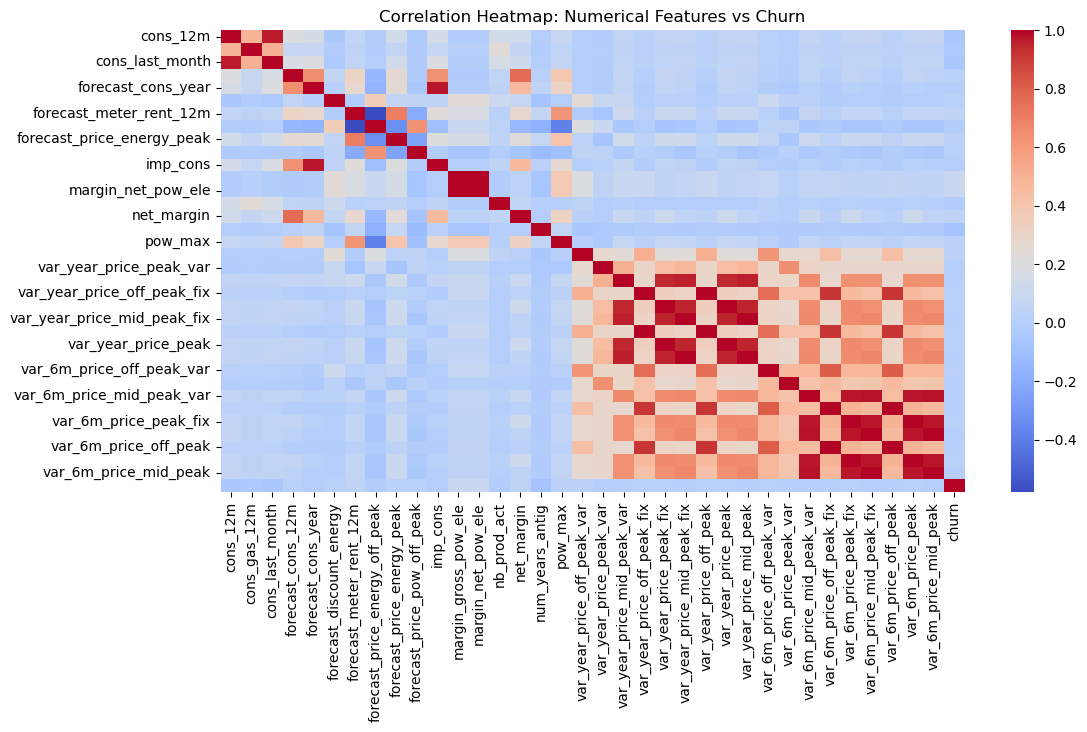

In [344]:
numeric_col = ['cons_12m', 'cons_gas_12m', 'cons_last_month',
        'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy',
       'forecast_meter_rent_12m', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak',
       'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'nb_prod_act',     
       'net_margin', 'num_years_antig', 'pow_max',
       'var_year_price_off_peak_var', 'var_year_price_peak_var',
       'var_year_price_mid_peak_var', 'var_year_price_off_peak_fix',
       'var_year_price_peak_fix', 'var_year_price_mid_peak_fix',
       'var_year_price_off_peak', 'var_year_price_peak',
       'var_year_price_mid_peak', 'var_6m_price_off_peak_var',
       'var_6m_price_peak_var', 'var_6m_price_mid_peak_var',
       'var_6m_price_off_peak_fix', 'var_6m_price_peak_fix',
       'var_6m_price_mid_peak_fix', 'var_6m_price_off_peak',
       'var_6m_price_peak', 'var_6m_price_mid_peak'
]

# df heatmap: to find correlation intensity between features
plt.figure(figsize=(12,6))
sns.heatmap(df[numeric_col + ['churn']].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap: Numerical Features vs Churn")
plt.show()

In [ ]:
# Drop features highly correlated to each other
cols_drop = ['var_6m_price_mid_peak_var',
       'var_6m_price_mid_peak_fix', 'var_6m_price_mid_peak', 'forecast_meter_rent_12m',
       'forecast_cons_year', 'cons_last_month','var_year_price_mid_peak', 'var_year_price_mid_peak_fix', 
       'var_year_price_mid_peak_var', 'margin_gross_pow_ele', 'var_year_price_peak_fix', 
       'var_year_price_peak', 'var_year_price_off_peak_fix', 'var_6m_price_off_peak', 'var_6m_price_peak']

df.drop(columns=cols_drop, inplace=True)

In [346]:
df.columns

Index(['id', 'channel_sales', 'cons_12m', 'cons_gas_12m', 'date_activ',
       'date_end', 'date_modif_prod', 'date_renewal', 'forecast_cons_12m',
       'forecast_discount_energy', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas',
       'imp_cons', 'margin_net_pow_ele', 'nb_prod_act', 'net_margin',
       'num_years_antig', 'origin_up', 'pow_max',
       'var_year_price_off_peak_var', 'var_year_price_peak_var',
       'var_year_price_off_peak', 'var_6m_price_off_peak_var',
       'var_6m_price_peak_var', 'var_6m_price_off_peak_fix',
       'var_6m_price_peak_fix', 'churn'],
      dtype='object')

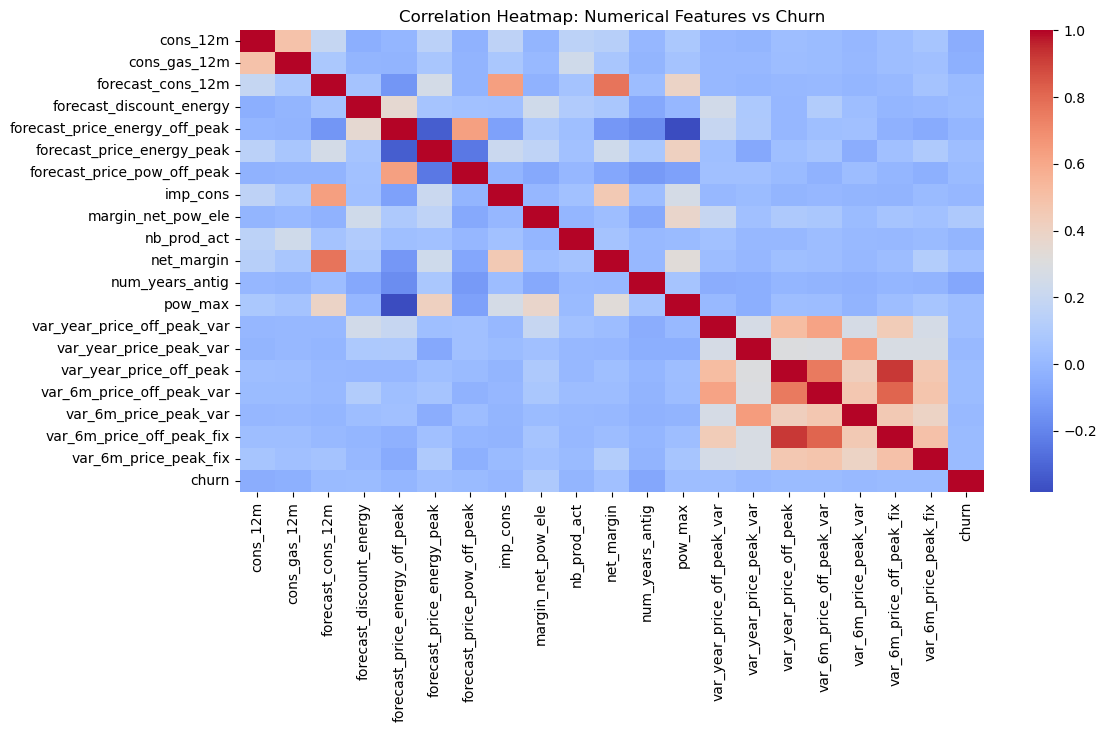

In [347]:
left_cols = ['cons_12m', 'cons_gas_12m', 'forecast_cons_12m',
       'forecast_discount_energy', 'forecast_price_energy_off_peak',
       'forecast_price_energy_peak', 'forecast_price_pow_off_peak',
       'imp_cons', 'margin_net_pow_ele', 'nb_prod_act', 'net_margin',
       'num_years_antig', 'pow_max', 'var_year_price_off_peak_var', 'var_year_price_peak_var',
       'var_year_price_off_peak', 'var_6m_price_off_peak_var',
       'var_6m_price_peak_var', 'var_6m_price_off_peak_fix',
       'var_6m_price_peak_fix']

# df heatmap after removing highly correlated features
plt.figure(figsize=(12,6))
sns.heatmap(df[left_cols + ['churn']].corr(), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap: Numerical Features vs Churn")
plt.show()

#### Feature engineering in client data

- Convert to datetime neccessary features.
- Find duration a customer has been with powerCo.
- Calculate the difference in consumption for current prices and forecasted prices.
- Calculate the difference in energy price at off peak period in a year and 6 months.
- Encode categorical features with more than two categories using One-hot encode.
- Label encode binary column 'has_gas'.
- Drop original date columns.
- Move churn to the last column 

In [ ]:
def feature_engineering(df):

    """
    Perform feature engineering on the input DataFrame.

    This function creates new features from date columns, calculates consumption and pricing differences,
    encodes categorical variables, and organizes the DataFrame for modeling.

    Parameters:
    df (pd.DataFrame): Input DataFrame containing customer and energy usage data.

    Returns:
    pd.DataFrame: Transformed DataFrame with engineered features ready for modeling.
    """

    df = df.copy()

    date_cols = ['date_activ', 'date_end']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col])

    df['customer_lifetime_days'] = (df['date_end'] - df['date_activ']).dt.days// 365

    df['forecast_error'] = df['forecast_cons_12m'] - df['cons_12m']
    df['discount_to_price_ratio'] = df['forecast_discount_energy'] / (
        df['forecast_price_energy_peak'] + 1
    )

    df['off_peak_price_var_diff'] = df['var_year_price_off_peak_var'] - df['var_6m_price_off_peak_var']
    df['peak_price_var_diff'] = df['var_year_price_peak_var'] - df['var_6m_price_peak_var']

    df['churn_by_customer_lifetime'] = df.groupby('customer_lifetime_days')['churn'].transform('mean')
    df['churn_by_channel'] = df.groupby('channel_sales')['churn'].transform('mean')
 
    categorical_cols = ['channel_sales', 'origin_up']
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)

    le = LabelEncoder()
    df['has_gas'] = le.fit_transform(df['has_gas'])

    df = df.drop(columns=date_cols)

    cols = [c for c in df.columns if c != 'churn'] + ['churn']
    df = df[cols]

    return df


In [349]:
df = feature_engineering(df)

df.head()

,id,cons_12m,cons_gas_12m,date_modif_prod,date_renewal,forecast_cons_12m,forecast_discount_energy,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,...,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp,churn
0,24011ae4ebbe3035111d65fa7c15bc57,0,54946,2015-11-01,2015-06-23,0.00,0.0,0.114481,0.098142,40.606701,...,1,0,0,0,0,0,0,1,0,1
1,d29c2c54acc38ff3c0614d0a653813dd,4660,0,2009-08-21,2015-08-31,189.95,0.0,0.145711,0.000000,44.311378,...,0,0,0,0,0,1,0,0,0,0
2,764c75f661154dac3a6c254cd082ea7d,544,0,2010-04-16,2015-04-17,47.96,0.0,0.165794,0.087899,44.311378,...,1,0,0,0,0,1,0,0,0,0
3,bba03439a292a1e166f80264c16191cb,1584,0,2010-03-30,2015-03-31,240.04,0.0,0.146694,0.000000,44.311378,...,0,1,0,0,0,1,0,0,0,0
4,149d57cf92fc41cf94415803a877cb4b,4425,0,2010-01-13,2015-03-09,445.75,0.0,0.116900,0.100015,40.606701,...,0,0,0,0,0,1,0,0,0,0


Dropping date columns that won't be needed for the model

In [350]:
cols = ['date_modif_prod', 'date_renewal']
df.drop(columns=cols, inplace=True)

The customers are likely to churn before reaching customer lifetime of 5 months and when using channel_sales_foosdfpfkusacimwkcsosbicdxkicaua. This means once the customers have passed lifetime of 4 months there is a good chance they will be retained, especially when not using the sales channel foosdfpfkusacimwkcsosbicdxkicaua.

In [357]:
df_subset = df[['channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci',
                'channel_sales_epumfxlbckeskwekxbiuasklxalciiuu',
                'channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa',
                'channel_sales_foosdfpfkusacimwkcsosbicdxkicaua',
                'channel_sales_lmkebamcaaclubfxadlmueccxoimlema',
                'channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds',
                'channel_sales_usilxuppasemubllopkaafesmlibmsdf',
                'customer_lifetime_days', 'churn_by_customer_lifetime', 'churn_by_channel']]

# Sort and drop duplicate rows
unique_rows = df_subset.sort_values(by='customer_lifetime_days', ascending=False).drop_duplicates(subset=['customer_lifetime_days'])
unique_rows

,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_epumfxlbckeskwekxbiuasklxalciiuu,channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,customer_lifetime_days,churn_by_customer_lifetime,churn_by_channel
4071,0,0,0,0,0,0,0,13,0.095238,0.075973
12939,0,0,0,0,0,0,0,12,0.083333,0.075973
7799,0,0,0,0,0,0,0,11,0.059783,0.075973
7160,0,0,0,0,0,0,0,10,0.045455,0.075973
6073,0,0,0,0,0,0,0,9,0.012500,0.075973
588,0,0,0,0,0,0,0,8,0.047244,0.075973
9068,0,0,0,1,0,0,0,7,0.075472,0.121410
6896,0,0,0,1,0,0,0,6,0.075407,0.121410
9071,0,0,0,0,0,0,1,5,0.091999,0.100364
164,0,0,0,1,0,0,0,4,0.127473,0.121410


In [ ]:
df.describe().T 

,count,mean,std,min,25%,50%,75%,max
cons_12m,14606.0,159220.286252,573465.264198,0.000000e+00,5674.750000,1.411550e+04,40763.750000,6.207104e+06
cons_gas_12m,14606.0,28092.375325,162973.059057,0.000000e+00,0.000000,0.000000e+00,0.000000,4.154590e+06
forecast_cons_12m,14606.0,1868.614880,2387.571531,0.000000e+00,494.995000,1.112875e+03,2401.790000,8.290283e+04
forecast_discount_energy,14606.0,0.966726,5.108289,0.000000e+00,0.000000,0.000000e+00,0.000000,3.000000e+01
forecast_price_energy_off_peak,14606.0,0.137283,0.024623,0.000000e+00,0.116340,1.431660e-01,0.146348,2.739630e-01
forecast_price_energy_peak,14606.0,0.050491,0.049037,0.000000e+00,0.000000,8.413800e-02,0.098837,1.959750e-01
forecast_price_pow_off_peak,14606.0,43.130056,4.485988,0.000000e+00,40.606701,4.431138e+01,44.311378,5.926638e+01
has_gas,14606.0,0.181501,0.385446,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000e+00
imp_cons,14606.0,152.786896,341.369366,0.000000e+00,0.000000,3.739500e+01,193.980000,1.504279e+04
margin_net_pow_ele,14606.0,24.562517,20.230280,0.000000e+00,14.280000,2.164000e+01,29.880000,3.746400e+02


In [ ]:
# Normalize features using min-max scale
num_cols = [
    'cons_12m', 'cons_gas_12m', 'forecast_cons_12m',
    'forecast_price_pow_off_peak', 'imp_cons',
    'margin_net_pow_ele', 'net_margin', 'num_years_antig',
    'pow_max', 'var_6m_price_off_peak_fix',
    'var_6m_price_peak_fix', 'customer_lifetime_days',
    'forecast_error', 'forecast_discount_energy',
    'nb_prod_act', 'var_year_price_off_peak', 'discount_to_price_ratio'
]

# Initialize scaler
scaler = MinMaxScaler()

# Fit + transform
df[num_cols] = scaler.fit_transform(df[num_cols])

df.describe().T

,count,mean,std,min,25%,50%,75%,max
cons_12m,14606.0,0.025651,0.092389,0.000000,9.142347e-04,2.274088e-03,0.006567,1.000000
cons_gas_12m,14606.0,0.006762,0.039227,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000
forecast_cons_12m,14606.0,0.022540,0.028800,0.000000,5.970785e-03,1.342385e-02,0.028971,1.000000
forecast_discount_energy,14606.0,0.032224,0.170276,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000
forecast_price_energy_off_peak,14606.0,0.137283,0.024623,0.000000,1.163400e-01,1.431660e-01,0.146348,0.273963
forecast_price_energy_peak,14606.0,0.050491,0.049037,0.000000,0.000000e+00,8.413800e-02,0.098837,0.195975
forecast_price_pow_off_peak,14606.0,0.727732,0.075692,0.000000,6.851558e-01,7.476647e-01,0.747665,1.000000
has_gas,14606.0,0.181501,0.385446,0.000000,0.000000e+00,0.000000e+00,0.000000,1.000000
imp_cons,14606.0,0.010157,0.022693,0.000000,0.000000e+00,2.485909e-03,0.012895,1.000000
margin_net_pow_ele,14606.0,0.065563,0.053999,0.000000,3.811659e-02,5.776212e-02,0.079757,1.000000


In [ ]:
print(diff.shape)
print(df.shape)

(16096, 15)
(14606, 42)


In [ ]:
# Merge on 'id' 
df_merged = df.merge(diff, on='id')

# Move churn to the last column
cols = [c for c in df_merged.columns if c != 'churn'] + ['churn']
df_merged = df_merged[cols]

In [ ]:
print(f'Total no. of clients in df dataset (engineered client data) is {diff.shape}')
print(f'Total no. of clients in diff dataset (engineered features of price_df) is {df.shape}')
print(f'Total number of clients after merging is {df_merged.shape}')

Total no. of clients in df dataset (engineered client data) is (16096, 15)
Total no. of clients in diff dataset (engineered features of price_df) is (14606, 42)
Total number of clients after merging is (14606, 56)


A total of 16096 - 14606 = 1490 clients with missing data in client dataset is observed

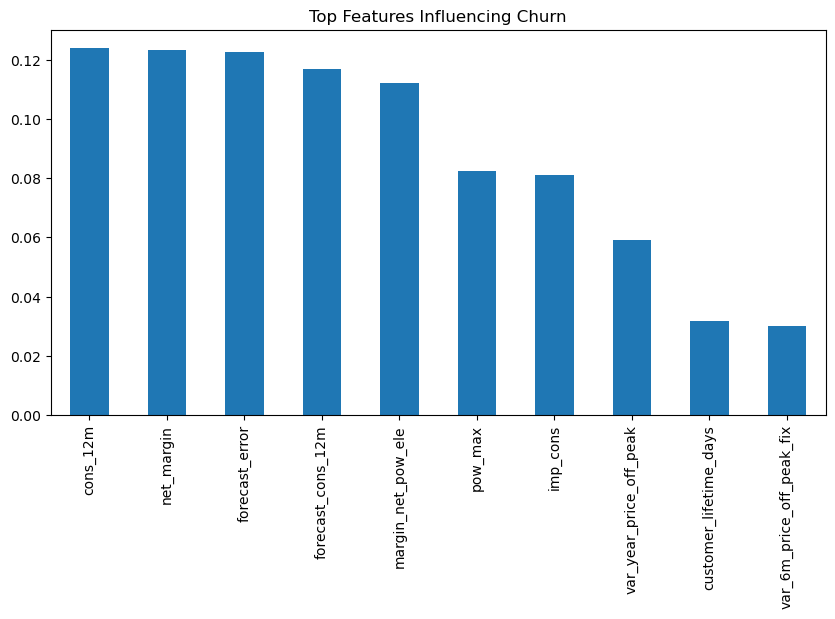

In [ ]:
# Visualizing top features that influence churn
X = df_merged[num_cols].fillna(0)   
y = df_merged['churn']

model = RandomForestClassifier(random_state=42)
model.fit(X, y)

importances = pd.Series(model.feature_importances_, index=num_cols).sort_values(ascending=False)
importances.head(10).plot(kind='bar', figsize=(10,5), title="Top Features Influencing Churn")
plt.show()